In [4]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# Data Overview

 **Loading the dataset, named dataframe as austo**

In [74]:
austo = pd.read_csv("D:\\PGP_Austin_DS\\Python _for_DS\\Python_for_DS_P1\\Dataset\\austo_automobile .csv")

 The first 5 rows of the dataset

In [6]:
austo.head()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.0,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.0,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.0,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.0,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.0,139900,57000,SUV


 The last 5 rows of the dataset

In [7]:
austo.tail()

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
1576,22,Male,Salaried,Single,Graduate,2,No,Yes,No,33300,0.0,33300,27000,Hatchback
1577,22,Male,Business,Married,Graduate,4,No,No,No,32000,NaN,32000,31000,Hatchback
1578,22,Male,Business,Single,Graduate,2,No,Yes,No,32900,0.0,32900,30000,Hatchback
1579,22,Male,Business,Married,Graduate,3,Yes,Yes,No,32200,NaN,32200,24000,Hatchback
1580,22,Male,Salaried,Married,Graduate,4,No,No,No,31600,0.0,31600,31000,Hatchback


**Checking the data types of the dataset**

In [8]:
austo.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1581 entries, 0 to 1580
Data columns (total 14 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Age               1581 non-null   int64  
 1   Gender            1528 non-null   object 
 2   Profession        1581 non-null   object 
 3   Marital_status    1581 non-null   object 
 4   Education         1581 non-null   object 
 5   No_of_Dependents  1581 non-null   int64  
 6   Personal_loan     1581 non-null   object 
 7   House_loan        1581 non-null   object 
 8   Partner_working   1581 non-null   object 
 9   Salary            1581 non-null   int64  
 10  Partner_salary    1475 non-null   float64
 11  Total_salary      1581 non-null   int64  
 12  Price             1581 non-null   int64  
 13  Make              1581 non-null   object 
dtypes: float64(1), int64(5), object(8)
memory usage: 173.1+ KB


In [9]:
austo['Partner_salary'].dtype

dtype('float64')

There are some missing values in categorical data Gender (53 values are missing) need to be treated.
The column Partner_salary is of float type due to the presence of missing values (NaNs) and decimal values. 

**Note : The data in the Price ,Salary,Total salary and Partner salary column is in Dollors.**

**Statistical summary of the dataset**

In [10]:
austo.describe().T

,count,mean,std,min,25%,50%,75%,max
Age,1581.0,31.922201,8.425978,22.0,25.0,29.0,38.0,54.0
No_of_Dependents,1581.0,2.457938,0.943483,0.0,2.0,2.0,3.0,4.0
Salary,1581.0,60392.220114,14674.825044,30000.0,51900.0,59500.0,71800.0,99300.0
Partner_salary,1475.0,20225.559322,19573.149277,0.0,0.0,25600.0,38300.0,80500.0
Total_salary,1581.0,79625.996205,25545.857768,30000.0,60500.0,78000.0,95900.0,171000.0
Price,1581.0,35597.722960,13633.636545,18000.0,25000.0,31000.0,47000.0,70000.0


1. The age of customers ranges from 22 to 54, with an average age of 32.
2. Around 50% of customers are 29, shows that half of the buyers are of young age.
3. Customers have 2 to 3 dependents on average, with some having none and a maximum of 4.
4. The average individual salary is 60,392, and 75% of customers earn below 71,800.The highest recorded salary is 99,300.
5. Partner salary data is missing for 106 customers as the data available only for 1475 out of 1581.
6. Many partners have 0 income, possibly indicating unemployment, and 50% are earning 25,600.
7. The combined household income averages 79,626, with the highest going up to 1,71,000.
8. The average price paid for a car is 35,598. 50% of the purchases are below 31,000, suggesting a preference for budget or mid-range models.

**Shape of the dataset**

In [11]:
austo.shape

(1581, 14)

The dataset contains 1,581 rows and 14 columns capturing customer and automobile-related information.

**checking the null values**

In [12]:
austo.isnull().sum()

Age                   0
Gender               53
Profession            0
Marital_status        0
Education             0
No_of_Dependents      0
Personal_loan         0
House_loan            0
Partner_working       0
Salary                0
Partner_salary      106
Total_salary          0
Price                 0
Make                  0
dtype: int64

There are 53 missing values in Gender and 106 missing values in Partner_salary, Need to be treated.

In [13]:
austo['Gender'].fillna(austo['Gender'].mode()[0], inplace=True)

In [14]:
austo['Gender'].isnull().sum()

0

In [15]:
austo['Partner_salary'].dtype

dtype('float64')

In [16]:
austo['Partner_salary'] = austo['Partner_salary'].fillna(austo['Partner_salary'].mean())

In [17]:
austo['Partner_salary'].isnull().sum()

0

In [18]:
austo['Partner_salary'].mean()

20225.559322033896

In [19]:
austo.isnull().sum()

Age                 0
Gender              0
Profession          0
Marital_status      0
Education           0
No_of_Dependents    0
Personal_loan       0
House_loan          0
Partner_working     0
Salary              0
Partner_salary      0
Total_salary        0
Price               0
Make                0
dtype: int64

Missing values in the Partner_salary column and Gender column were successfully treated using the column’s mean and mode. After imputation, there are no missing values in this column.

In [20]:
austo.head(50)

,Age,Gender,Profession,Marital_status,Education,No_of_Dependents,Personal_loan,House_loan,Partner_working,Salary,Partner_salary,Total_salary,Price,Make
0,53,Male,Business,Married,Post Graduate,4,No,No,Yes,99300,70700.000000,170000,61000,SUV
1,53,Femal,Salaried,Married,Post Graduate,4,Yes,No,Yes,95500,70300.000000,165800,61000,SUV
2,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,97300,60700.000000,158000,57000,SUV
3,53,Female,Salaried,Married,Graduate,2,Yes,No,Yes,72500,70300.000000,142800,61000,SUV
4,53,Male,Salaried,Married,Post Graduate,3,No,No,Yes,79700,60200.000000,139900,57000,SUV
5,53,Female,Salaried,Married,Post Graduate,3,No,No,Yes,79800,60500.000000,140300,57000,SUV
6,53,Female,Salaried,Married,Post Graduate,3,Yes,No,Yes,80900,50800.000000,131700,51000,SUV
7,52,Male,Salaried,Married,Graduate,4,No,No,Yes,79100,40400.000000,119500,68000,SUV
8,52,Male,Salaried,Married,Post Graduate,4,No,No,No,89400,0.000000,89400,61000,SUV
9,52,Male,Salaried,Married,Post Graduate,3,No,No,No,83700,0.000000,83700,57000,SUV


**Checking if any duplicate values are present in data**

In [21]:
austo.duplicated().sum()

0

There are no duplicate values present in the data 

# Univariate Analysis

**Understanding the distribution of Categorical columns**

**1. Distribution of Profession**

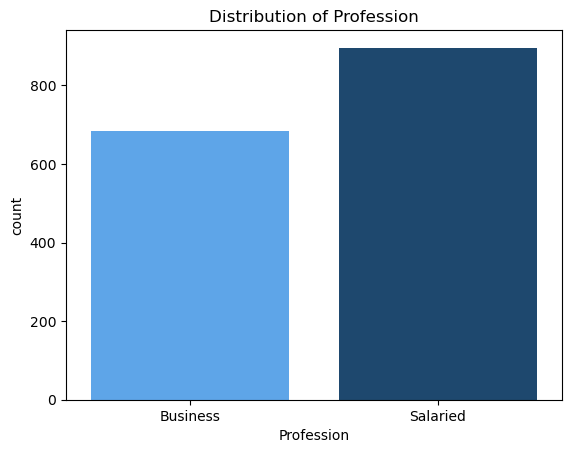

In [22]:
sns.countplot(data = austo,x = 'Profession',hue = 'Profession',palette={'Business': '#47A6FF', 'Salaried': '#11497B'})
plt.title('Distribution of Profession')
plt.show()

The above distribution says that "majority of the customers belong to the Salaried profession group, followed by the Business group. This shows that salaried individuals are the key customer group and can be the main focus for future marketing campaigns.

**2. Distribution of Gender**

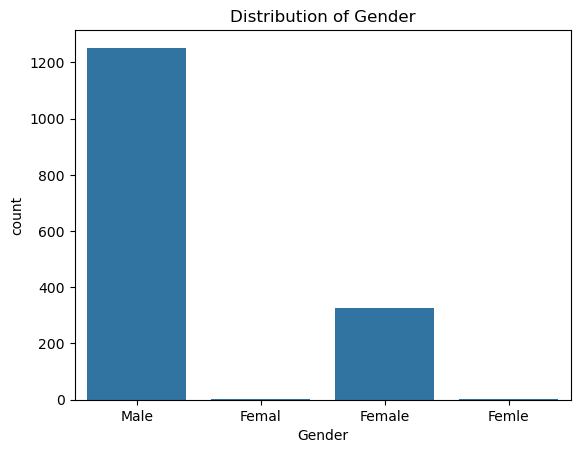

In [23]:
sns.countplot(data = austo, x= 'Gender')
plt.title('Distribution of Gender')
plt.show()

As i see from the above distribution, there is a data irregularity (spelling inconsistencies) which needs to be fixed for accurate analysis.

In [24]:
austo['Gender'] = austo['Gender'].replace(['Femal','Femle'],'Female')

In [25]:
austo['Gender'].value_counts()

Gender
Male      1252
Female     329
Name: count, dtype: int64

**After fixing Data Irregularities checking the distribution of Gender**

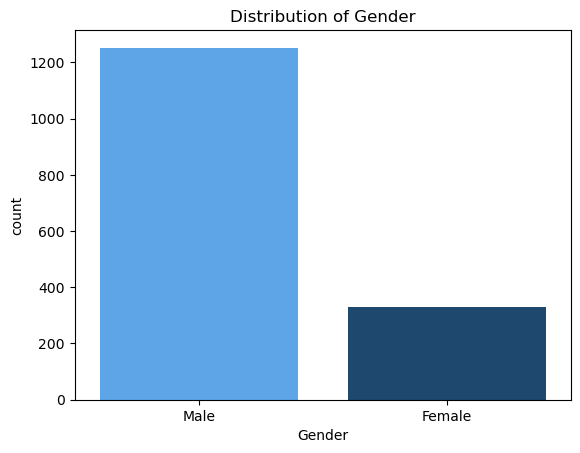

In [26]:
sns.countplot(data = austo,x = 'Gender',hue = 'Gender',palette={'Male': '#47A6FF', 'Female': '#11497B'})
plt.title('Distribution of Gender')
plt.show()

From the above distribution, majority of the car buyers are male, while female buyers make up a smaller portion. 
This indicates that marketing strategies can be more focused on male customers, and new campaigns can be designed to attract more female customers.

In [27]:
austo['Gender'].value_counts(normalize = True) * 100

Gender
Male      79.190386
Female    20.809614
Name: proportion, dtype: float64

Around 80% of customers are male, suggesting a strong preference among male buyers

**3. Distribution of Education** 

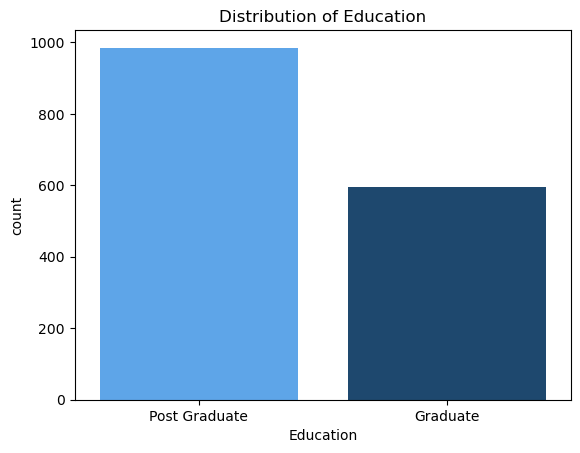

In [28]:
sns.countplot(data = austo,x = 'Education',hue = 'Education',palette={'Post Graduate': '#47A6FF', 'Graduate': '#11497B'})
plt.title('Distribution of Education')
plt.show()

In [29]:
austo['Education'].value_counts(normalize = True) * 100

Education
Post Graduate    62.30234
Graduate         37.69766
Name: proportion, dtype: float64

While the distribution shows that a majority of customers are postgraduates (around 62%), this variable does not appear to have a significant influence on customer behavior or purchase decisions in this context. Therefore, it may not be strong key factor for marketing insights.

**4 . Distribution of Partner Working**

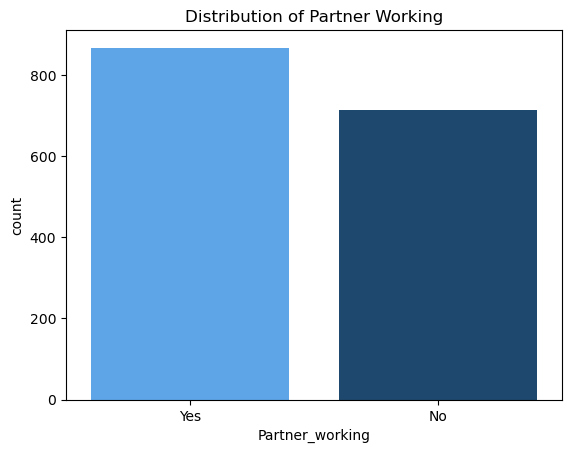

In [30]:
sns.countplot(data = austo, x = 'Partner_working',hue ='Partner_working',palette={'Yes': '#47A6FF', 'No': '#11497B'})
plt.title('Distribution of Partner Working')
plt.show()

From the above observation, we can see that majority of partners are working, but the difference isn't very large.
This shows that while many customers have dual incomes, a significant number still rely on a single earner, which is important to keep in mind for affordability.

**5. Distribution of Make**

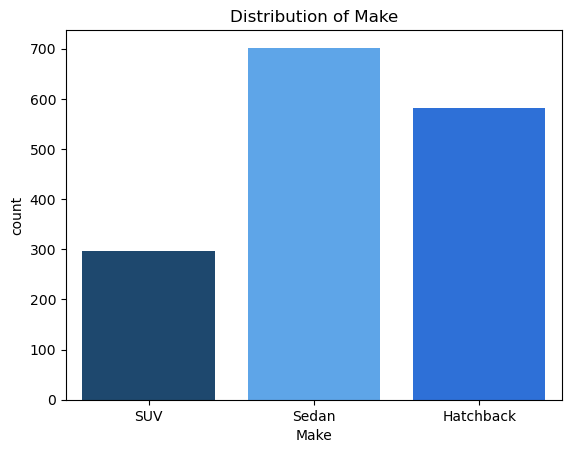

In [31]:
sns.countplot(data = austo,x = 'Make',hue = 'Make',palette={'Sedan': '#47A6FF', 'SUV': '#11497B','Hatchback':'#126AF3'})
plt.title('Distribution of Make')
plt.show()

From the above distribution, most customers have purchased Sedans and Hatchbacks, while SUVs have the least number of buyers. This could indicate that cost may be a barrier for SUV purchases, and customers may prefer more budget-friendly or fuel-efficient options.

**6. Distribution of Marital Status**

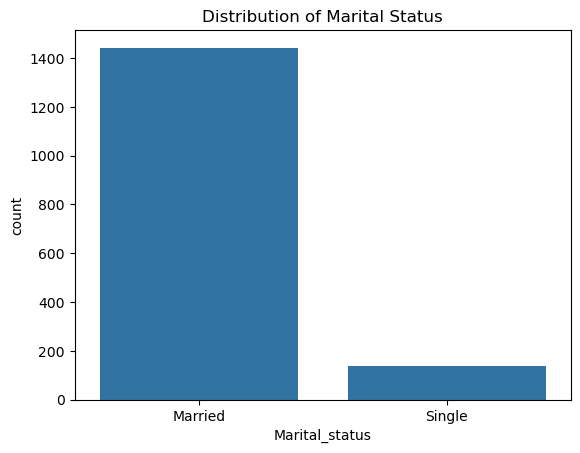

In [32]:
sns.countplot(data = austo, x = 'Marital_status')
plt.title('Distribution of Marital Status')
plt.show()

From the above distribution ,most customers are married, which suggests that many buyers could be family-oriented. These customers may prioritize comfort, safety, and budget-friendly vehicles, making them ideal targets for campaigns focused on family features or bundled finance options.

**7. Distribution of Personal Loan** 

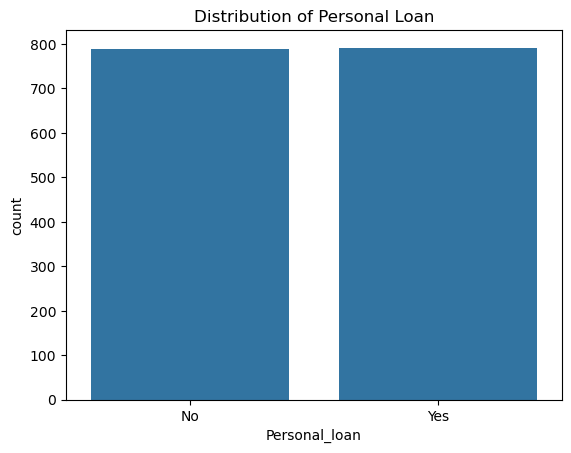

In [33]:
sns.countplot(data = austo, x = 'Personal_loan')
plt.title('Distribution of Personal Loan')
plt.show()

The distribution of personal loan is almost equal — around 50% of customers have taken a personal loan, and 50% haven’t. This indicates that personal financing plays a significant role in vehicle purchases and could be a key consideration for marketing EMI-based offers.

**8. Distribution of House Loan** 

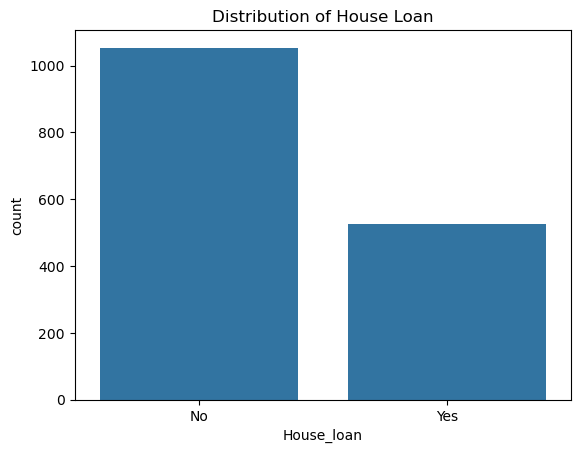

In [34]:
sns.countplot(data = austo, x = 'House_loan')
plt.title('Distribution of House Loan')
plt.show()

From the above distribution,only few customers have housing loan. However, further analysis is needed to understand how loan status affects automobile spending.

**Understanding the distribution of Numerical columns**

**1. Distribution of Age**

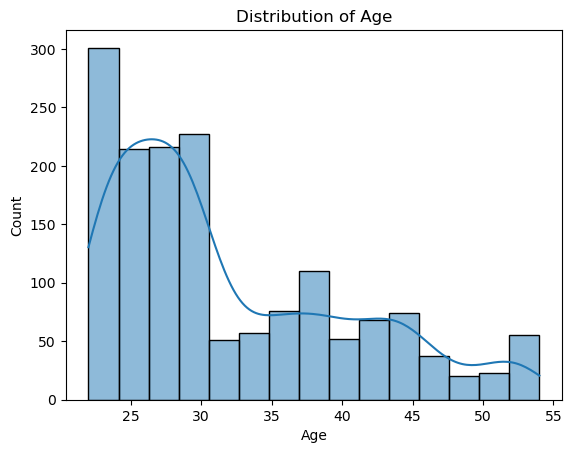

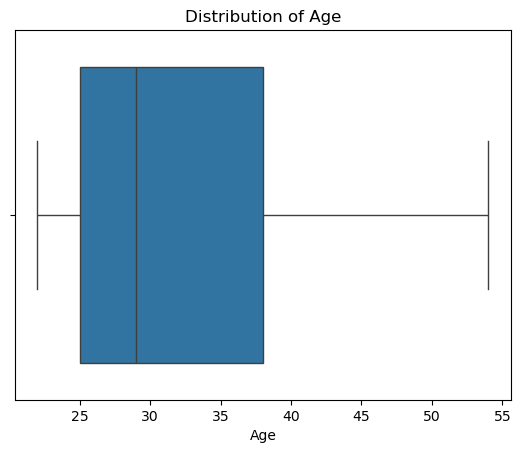

In [35]:
sns.histplot(data = austo,x = 'Age',kde = True)
plt.title('Distribution of Age')
plt.show()

sns.boxplot(data = austo,x = 'Age')
plt.title('Distribution of Age')
plt.show()

In [36]:
austo['Age'].min()

22

In [37]:
austo['Age'].max()

54

From the above distribution, the boxplot has a longer tail on the right side means that the age is right-skewed with most customers aged between 22 and 38 years.
If we see the boxplot,there are no outliers in the data, and the age spreads from 22 to 54 years.

**2. Distribution of No of Dependents**

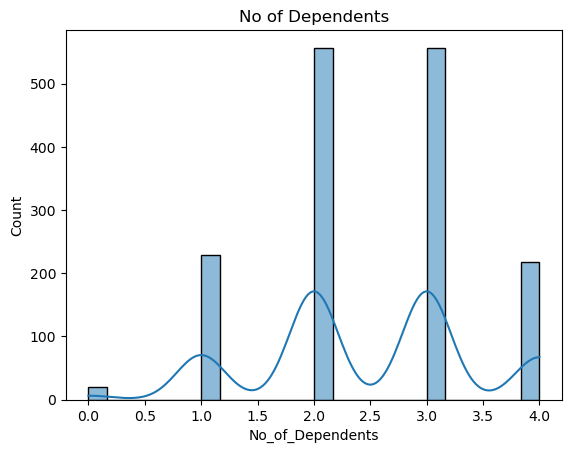

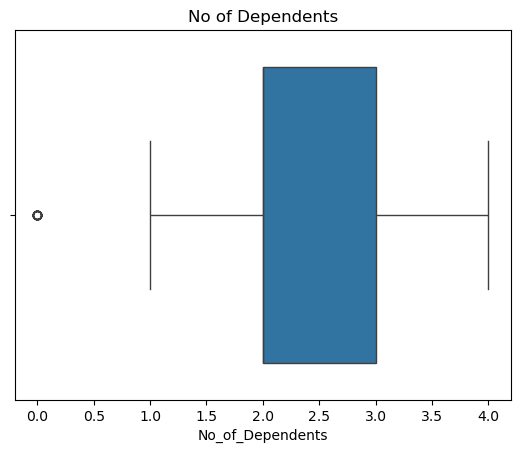

In [38]:
sns.histplot(data = austo,x = 'No_of_Dependents',kde = True)
plt.title('No of Dependents')
plt.show()

sns.boxplot(data = austo, x = 'No_of_Dependents')
plt.title('No of Dependents')
plt.show()

From the above distribution, we can see the number of dependents ranges from 0 to 4. Most customers have 2 or 3 dependents, and a small group has no dependents.
There are no significant outliers, and the data is fairly evenly distributed across the valid range.

**3. Distribution of Salary**

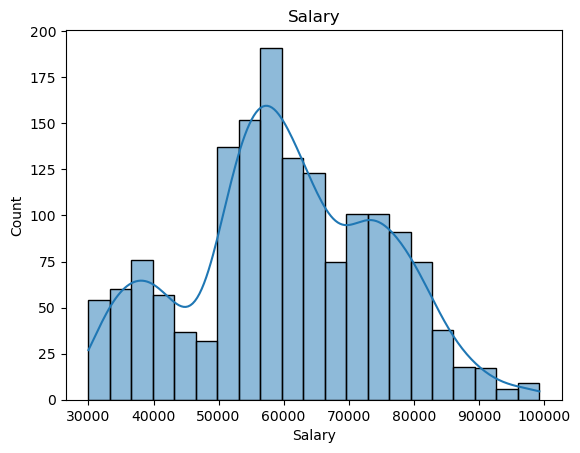

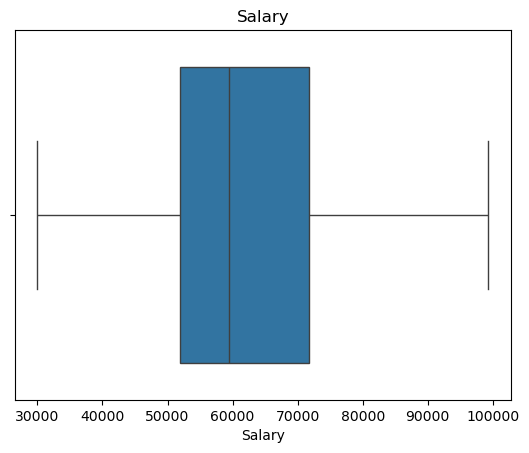

In [39]:
sns.histplot(data = austo,x = 'Salary',kde = True)
plt.title('Salary')
plt.show()

sns.boxplot(data = austo, x = 'Salary')
plt.title('Salary')
plt.show()

From the above distribution, we can see the most of the customers earn between 55,000 and 75,000, with salaries ranging from 30,000 to 99,300.
The distribution is slightly right-skewed, and no outliers are observed. This suggests that a majority of customers belong to a stable mid-income group, which is ideal for EMI-based marketing or mid-range vehicle promotions.

**4. Distribution of Partner Salary**

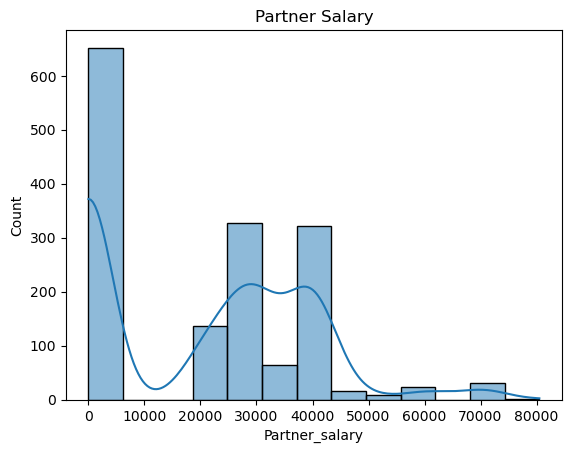

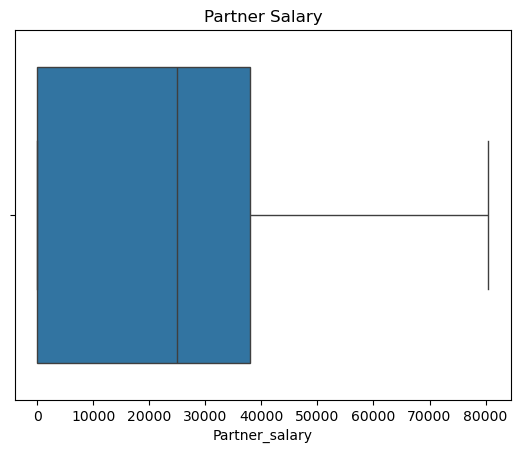

In [40]:
sns.histplot(data = austo,x = 'Partner_salary',kde = True)
plt.title('Partner Salary')
plt.show()

sns.boxplot(data = austo, x = 'Partner_salary')
plt.title('Partner Salary')
plt.show()

From the above distribution, we can say that partner salaries range from 0 to 80,500, but the majority earn 0 to 38,000, indicating that many partners are either unemployed or earn relatively low income.
The data is left-skewed, meaning most partner incomes are on the lower end.
This suggests that the customer may be the primary or sole earner, so offering budget-friendly vehicles or affordable financing options could be more effective.

**5. Distribution of Total Salary**

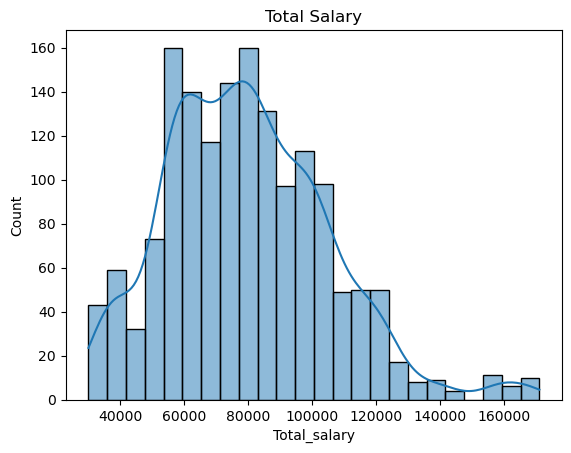

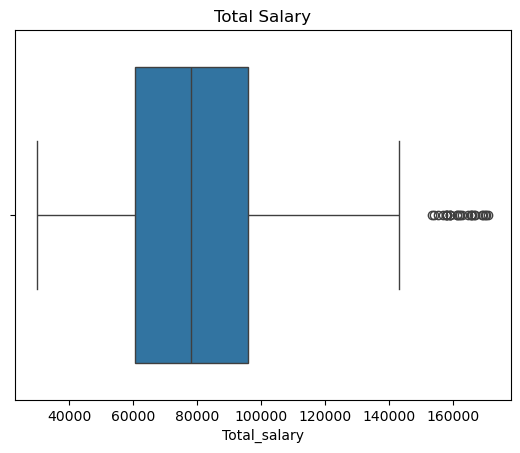

In [41]:
sns.histplot(data = austo,x = 'Total_salary',kde = True)
plt.title('Total Salary')
plt.show()

sns.boxplot(data = austo, x = 'Total_salary')
plt.title('Total Salary')
plt.show()

The total salary distribution is right-skewed, ranging from 30,000 to 1,71,000.
While a few customers earn significantly more, the majority earn below 1,00,000.
These high-income values are outliers, and although they were retained (or capped), the analysis and recommendations focus on the mid-income majority.
This suggests that SUVs may not be the primary interest, and budget to mid-range cars are more aligned with customer affordability.

In [42]:

Q1 = austo['Total_salary'].quantile(0.25)
Q3 = austo['Total_salary'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = austo[(austo['Total_salary'] < lower_bound) | (austo['Total_salary'] > upper_bound)]
print("Number of outliers in Total_salary:", len(outliers))
print(outliers[['Total_salary']])

Number of outliers in Total_salary: 27
     Total_salary
0          170000
1          165800
2          158000
17         165700
18         162900
19         159000
29         169000
30         165600
31         161100
41         166900
42         155200
49         170400
56         171000
57         154100
75         164700
76         161800
87         153500
98         169300
99         159100
103        162300
111        161100
116        166500
117        156900
130        158900
131        157700
277        157900
329        158200


If we see, there are 27 outliers in Total_salary.
These need to capped at the 95th percentile to reduce distortion while retaining their contribution to the analysis.

In [43]:
cap_value = austo['Total_salary'].quantile(0.95)
austo['Total_salary'] = np.where(austo['Total_salary'] > cap_value, cap_value, austo['Total_salary'])

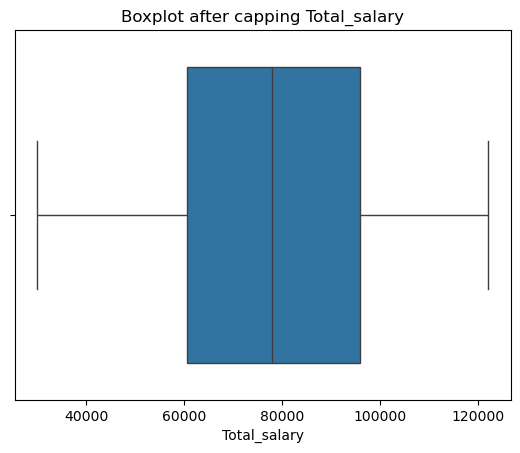

In [44]:
sns.boxplot(data = austo, x= 'Total_salary')
plt.title('Boxplot after capping Total_salary')
plt.show()

In [45]:
austo['Total_salary'].max()

122100.0

The 95th percentile of Total_salary was calculated as 1,22,100.
All values above this were capped to ensure consistency in the data and avoid distortion due to extreme outliers.
After this treatment, the distribution appeared stable, and no outliers remained in the boxplot.

**6. Distribution of Price**

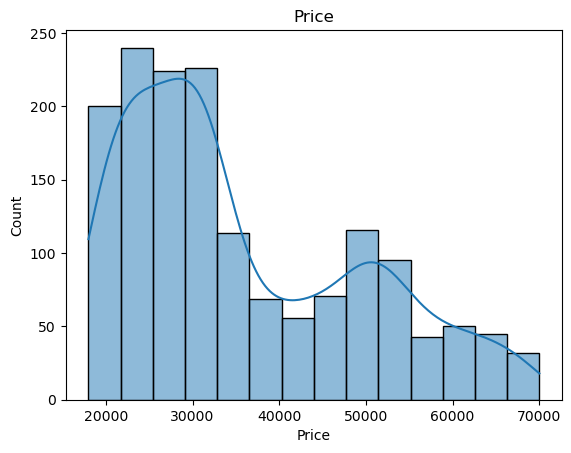

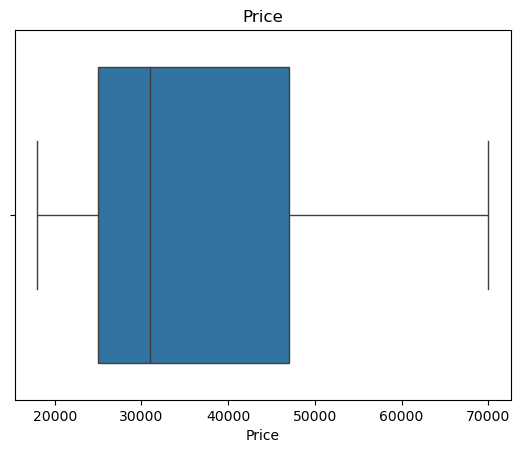

In [46]:
sns.histplot(data = austo,x = 'Price',kde = True)
plt.title('Price')
plt.show()

sns.boxplot(data = austo, x = 'Price')
plt.title('Price')
plt.show()

From the above observation,the price of car ranges from 18,000 to 70,000, with the majority of purchases falling between 18,000 and 35,000.
The data is right-skewed, indicating most people don’t have very high income. So, it makes sense to focus on selling more budget-friendly cars, which most customers can afford.

# Bivariate Analysis

In [47]:
numerical_cols = austo.select_dtypes(include=['int64', 'float64']).columns
print('numerical_columns:',list(numerical_cols))

categorical_cols = austo.select_dtypes(include = ['object']).columns
print('categorical columns:',list(categorical_cols))

numerical_columns: ['Age', 'No_of_Dependents', 'Salary', 'Partner_salary', 'Total_salary', 'Price']
categorical columns: ['Gender', 'Profession', 'Marital_status', 'Education', 'Personal_loan', 'House_loan', 'Partner_working', 'Make']


**Correlation between numerical columns**

<Axes: >

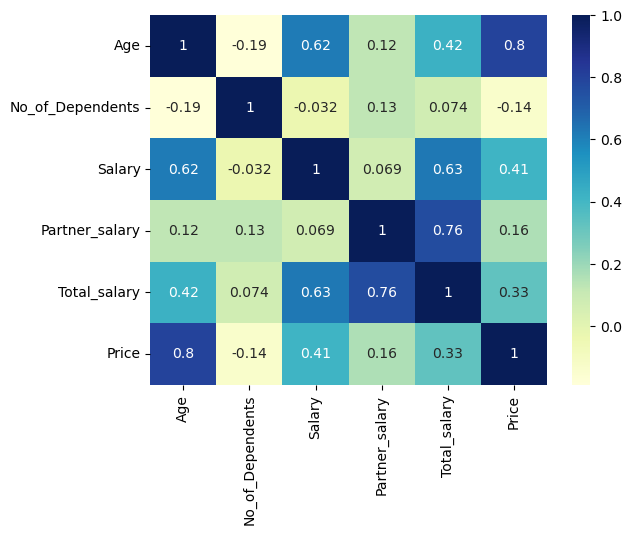

In [48]:
sns.heatmap(data = austo[['Age', 'No_of_Dependents', 'Salary', 'Partner_salary', 'Total_salary', 'Price']].corr(),annot = True,cmap='YlGnBu')

From the above correlation, we can see that Age and Price columns are highly correlated with each other, suggests that as customers grow older, they tend to invest more in higher-priced vehicles. 
The Total_salary and Partner_salary are also correlated with each other, which is expected since Total_salary includes the partner’s income.

**Relationship between all Numerical Variables and Numerical vs Categorical Variables**

**1. Relationship Between Age and Price**

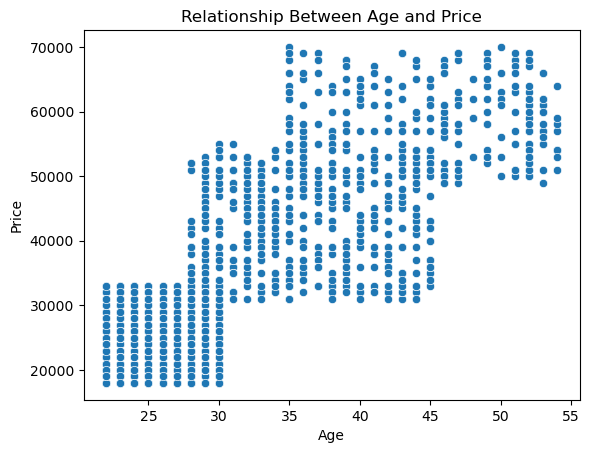

In [49]:
sns.scatterplot(data = austo,x= 'Age', y = 'Price')
plt.xlabel('Age')
plt.ylabel('Price')
plt.title('Relationship Between Age and Price')
plt.show()

From the above observation, the scatterplot shows that as customer age increases, the price of vehicles purchased also tends to rise.
This supports our earlier observation of a strong correlation.

**2. Relationship Between Age and Salary**

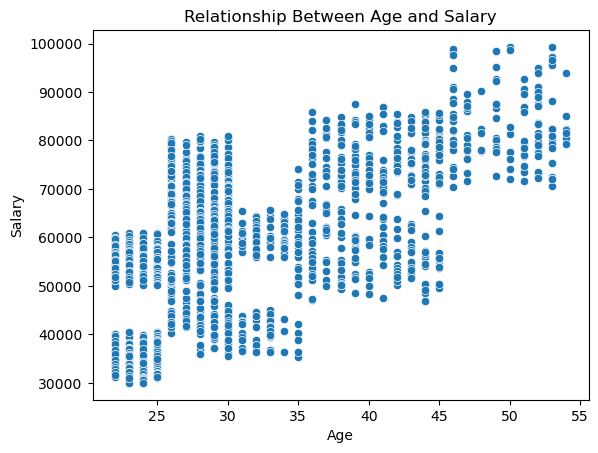

In [50]:
sns.scatterplot(data = austo,x= 'Age', y = 'Salary')
plt.xlabel('Age')
plt.ylabel('Salary')
plt.title('Relationship Between Age and Salary')
plt.show()

From the above observation, the scatterplot shows a positive relationship between age and salary. Older customers generally earn more, suggesting they may have higher purchasing power and could be potential targets for premium vehicles .

**3. Price by Gender**

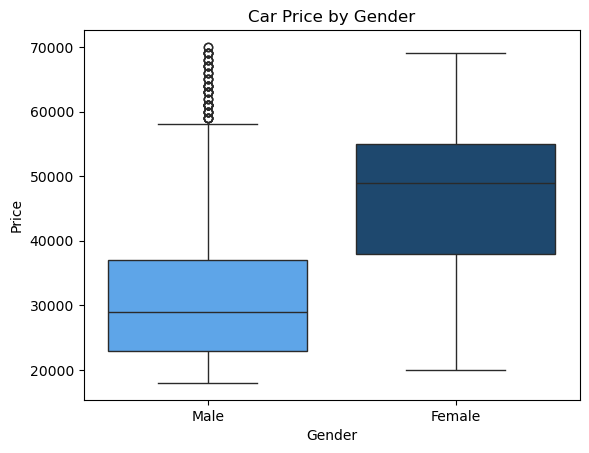

In [51]:
sns.boxplot(data = austo,x= 'Gender', y = 'Price',hue ='Gender',palette={'Male': '#47A6FF', 'Female': '#11497B'})
plt.title('Car Price by Gender')
plt.show()

From the above observation, the boxplot shows that female customers tend to purchase higher-priced vehicles on average compared to male customers.

**4. Salary by Profession**

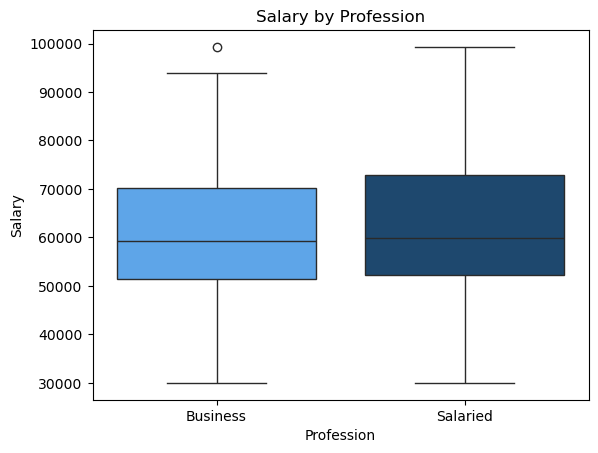

In [52]:
sns.boxplot(data=austo, x='Profession', y='Salary',hue = 'Profession',palette={'Business': '#47A6FF', 'Salaried': '#11497B'})
plt.title('Salary by Profession')
plt.show()

From the above boxplot, we can observe that both salaried and business professionals have similar salary distributions, with salaried individuals showing a slightly higher upper range and median.

In [53]:
austo.groupby('Profession')['Salary'].mean()

Profession
Business    59578.978102
Salaried    61013.950893
Name: Salary, dtype: float64

**5. Salary Distribution by Car Type**

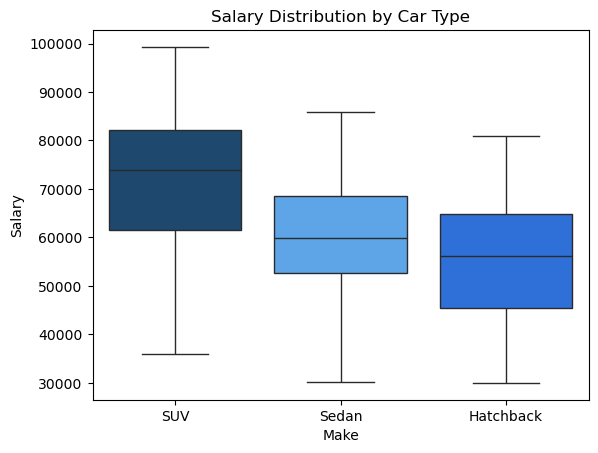

In [54]:
sns.boxplot(data=austo, x='Make', y='Salary',hue = 'Make',palette={'Sedan': '#47A6FF', 'SUV': '#11497B','Hatchback':'#126AF3'})
plt.title('Salary Distribution by Car Type')
plt.show()

From the above boxplot, we can see that Higher-earning customers are more likely to purchase SUVs, and 
Mid-income customers tend to choose Sedans, and lower-income customers prefer Hatchbacks.

**6 Make Preffered by Gender**

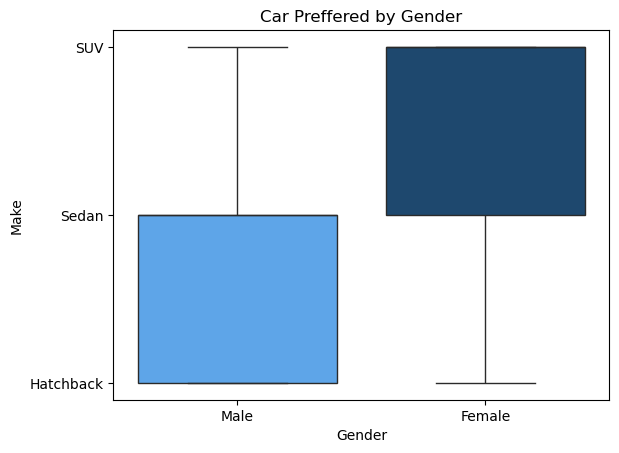

In [55]:
sns.boxplot(data = austo,x= 'Gender', y = 'Make',hue = 'Gender',palette={'Male': '#47A6FF', 'Female': '#11497B'})
plt.title('Car Preffered by Gender')
plt.show()

From the above observation, we can say that female customers are more likely to purchase higher-end vehicles such as Sedans and SUVs.
Male customers tend to purchase Hatchbacks.

**7. Car Price vs Personal Loan**

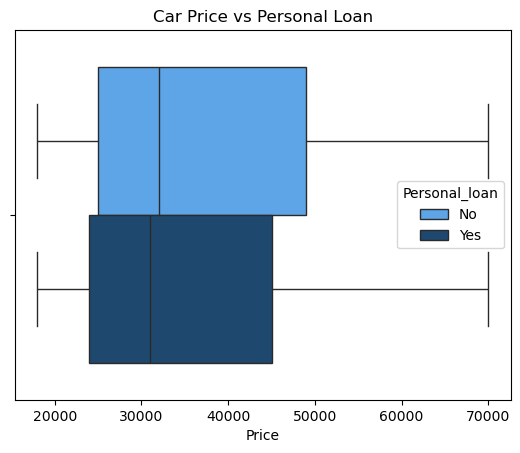

In [56]:
sns.boxplot(data = austo, hue='Personal_loan', x = 'Price',palette={'No': '#47A6FF', 'Yes': '#11497B'})
plt.title('Car Price vs Personal Loan')
plt.show()

From the above boxplot, we can say that customers without personal loans tend to purchase higher-priced vehicles and Customers with existing personal loans are more inclined to choose budget or mid-range vehicles.

**8. Partner Salary vs Car Price by Car Type**

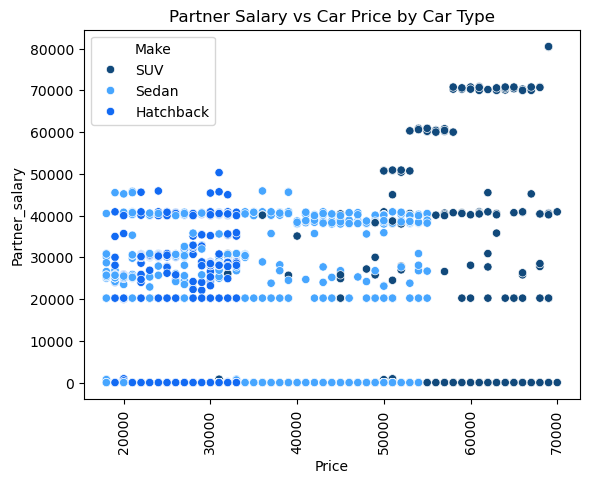

In [57]:
sns.scatterplot(data = austo,x= 'Price', y = 'Partner_salary',hue = 'Make',palette={'Sedan': '#47A6FF', 'SUV': '#11497B','Hatchback':'#126AF3'})
plt.title('Partner Salary vs Car Price by Car Type')
plt.xticks(rotation=90);
plt.show()

From the above scatterplot, we can say that customers with higher partner salaries are more likely to purchase SUVs, and those with moderate partner income tend to choose Sedans and customers whose partners have lower or no income are mostly opting for Hatchbacks.

**Just wanted to check , whether the customer have both perosnal loan and home loaan. If yes , what car model they have purchased.**

In [58]:
both_loans = austo[(austo['Personal_loan'] == 'Yes') & (austo['House_loan'] == 'Yes')]
print(both_loans['Make'].value_counts())

Make
Sedan        151
Hatchback    116
SUV           11
Name: count, dtype: int64


**9. Make Distribution Among Customers with Both Loans**

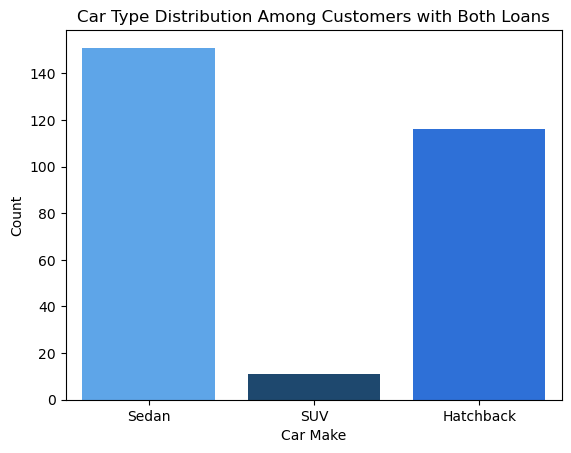

In [59]:
sns.countplot(data = both_loans,x = 'Make',hue = 'Make',palette={'Sedan': '#47A6FF', 'SUV': '#11497B','Hatchback':'#126AF3'})
plt.title('Car Type Distribution Among Customers with Both Loans')
plt.xlabel('Car Make')
plt.ylabel('Count')
plt.show()

From the above observation, we can say that customers with both loans opted for sedans and followed by hatchbacks.Very few customers preferred SUVs.

**10. Marital Status by Gender**

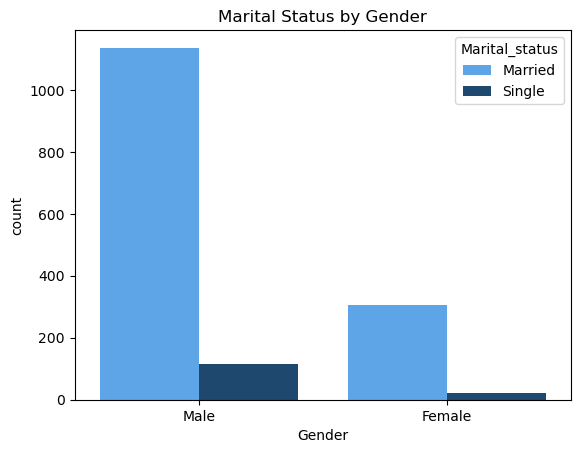

In [60]:
sns.countplot(data = austo,x = 'Gender',hue= 'Marital_status', palette={'Married': '#47A6FF', 'Single': '#11497B'})
plt.title('Marital Status by Gender')
plt.show()

From the above observation, the plot shows that the majority of both male and female customers are married.
However, married males significantly more compared to married females.

# Criteria : Key Questions

**1. Do men tend to prefer SUVs compared to women?**

In [61]:
prefer = austo[austo['Make'] == 'SUV']['Gender'].value_counts(normalize = True)
print(prefer)

Gender
Female    0.582492
Male      0.417508
Name: proportion, dtype: float64


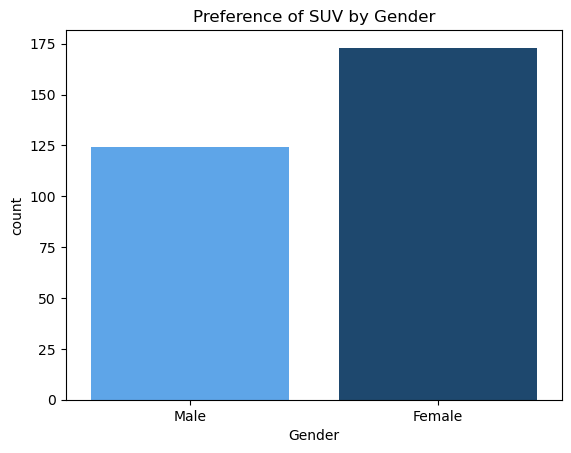

In [62]:
sns.countplot(data = austo[austo['Make'] == 'SUV'],x = 'Gender',palette = {'Male': '#47A6FF', 'Female': '#11497B'} )
plt.title('Preference of SUV by Gender')
plt.show()

From the above observation of code and plot, we can see that Female preference is more to Buy SUVs than Male. 58% of women prefered to buy the SUVs whereas only 41% of men prefered to buy SUVs.

**2. What is the likelihood of a salaried person buying a Sedan?**

In [63]:
Total_Salaried = austo[austo['Profession'] == 'Salaried']
Salaried_Sedan = Total_Salaried[Total_Salaried['Make']== 'Sedan']
likelihood = len(Salaried_Sedan)/len(Total_Salaried) * 100
print('The likelihood of Salaried Person buying a Sedan is :',likelihood)

The likelihood of Salaried Person buying a Sedan is : 44.19642857142857


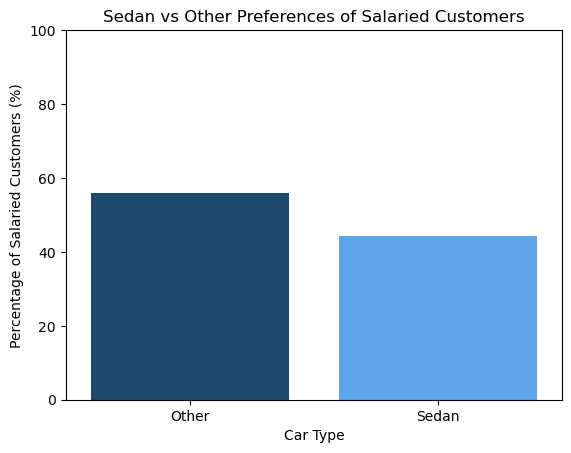

In [75]:
Total_Salaried['Car_Type'] = Total_Salaried['Make'].apply(lambda x: 'Sedan' if x == 'Sedan' else 'Other')

percentages = Total_Salaried['Car_Type'].value_counts(normalize=True) * 100
plot_data = percentages.reset_index()
plot_data.columns = ['Car_Type', 'Percentage']

sns.barplot(data=plot_data, x='Car_Type', y='Percentage', palette={'Sedan': '#47A6FF', 'Other': '#11497B'})
plt.title('Sedan vs Other Preferences of Salaried Customers')
plt.ylabel('Percentage of Salaried Customers (%)')
plt.xlabel('Car Type')
plt.ylim(0, 100)
plt.show()

From the above observation of code and plot, we can say that out of all salaried customers, approximately 44.2% chose to purchase a Sedan.

**3. What evidence or data supports Sheldon Cooper's claim that a salaried male is an easier target for a SUV sale over a Sedan sale?**

In [65]:
Salaried_male = austo[(austo['Profession']=='Salaried') & (austo['Gender']=='Male')]
SUV_Counts = len(Salaried_male[Salaried_male['Make']=='SUV'])
Sedan_Counts = len(Salaried_male[Salaried_male['Make']=='Sedan'])
print('Total no of SUV counts is:',SUV_Counts)
print('Total no of Sedan counts is:',Sedan_Counts)

Total no of SUV counts is: 90
Total no of Sedan counts is: 305


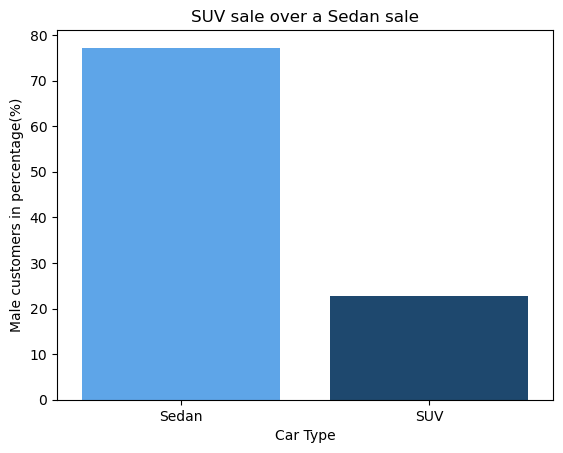

In [66]:
suv_sedan_data = Salaried_male[Salaried_male['Make'].isin(['Sedan', 'SUV'])]

percent_data = suv_sedan_data['Make'].value_counts(normalize=True) * 100
plot_data = percent_data.reset_index()
plot_data.columns = ['Make', 'Percentage']

sns.barplot(data= plot_data,x ='Make',y='Percentage', palette={'Sedan': '#47A6FF', 'SUV': '#11497B'})
plt.title('SUV sale over a Sedan sale')
plt.xlabel('Car Type')
plt.ylabel('Male customers in percentage(%)')
plt.show()

From the above observation we can say that among salaried male customers, approximately 77% purchased Sedans, while only 23% opted for SUVs. This confirms that Sedans are significantly more popular in this segment.
As Sedan purchased count is more than SUV, Sheldon Cooper's assumption doesn’t align with the data.

**4. How does the the amount spent on purchasing automobiles vary by gender?**

In [67]:
amount_by_gender = austo.groupby('Gender')['Price'].mean()
print(amount_by_gender)

Gender
Female    47705.167173
Male      32416.134185
Name: Price, dtype: float64


From the above observation if we see, Female customers spend an average of 47,705 on car purchases, and Male customers spend an average of 32,416.

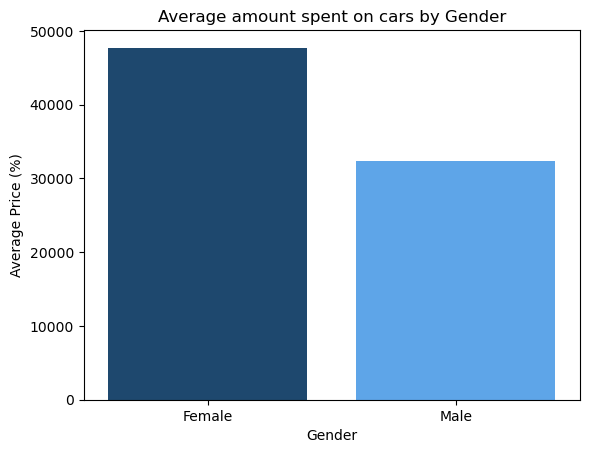

In [68]:
amount_by_gender = austo.groupby('Gender')['Price'].mean().reset_index()
sns.barplot(data = amount_by_gender,x = 'Gender',y = 'Price',palette={'Male': '#47A6FF', 'Female': '#11497B'})
plt.title('Average amount spent on cars by Gender')
plt.xlabel('Gender')
plt.ylabel('Average Price (%)')
plt.show()

From the above observation, it shows that female customers tend to purchase higher-priced vehicles compared to male customers.

**5. How much money was spent on purchasing automobiles by individuals who took a personal loan?**

In [69]:
money_indviduals = austo.groupby('Personal_loan')['Price'].sum()
print(money_indviduals)

Personal_loan
No     28990000
Yes    27290000
Name: Price, dtype: int64


From the above observation we can say that Customers without a personal loan have spent 28,990,000 in total on car purchases.
Customers with a personal loan have spent 27,290,000 in total.Customers with personal loans are active car buyers.Targeting personal loan holders with budget-friendly vehicles, custom EMI plans, offers to retain and expand this customer segment.

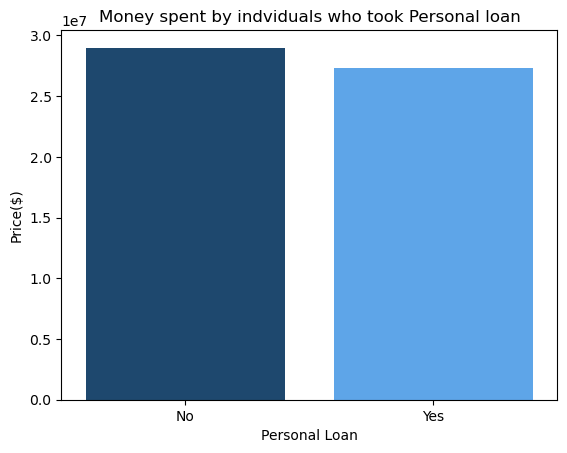

In [78]:
money_indviduals = austo.groupby('Personal_loan')['Price'].sum().reset_index()
sns.barplot(data = money_indviduals,x = 'Personal_loan', y = 'Price',palette={'Yes': '#47A6FF', 'No': '#11497B'})
plt.title('Money spent by indviduals who took Personal loan')
plt.xlabel('Personal Loan')
plt.ylabel('Price($)')
plt.show()

**6. How does having a working partner influence the purchase of higher-priced cars?**

In [71]:
partner_influence = austo.groupby(['Partner_working','Make'])['Price'].mean()
print(partner_influence)

Partner_working  Make     
No               Hatchback    26323.843416
                 SUV          56173.611111
                 Sedan        35354.166667
Yes              Hatchback    26614.617940
                 SUV          55496.732026
                 Sedan        34082.125604
Name: Price, dtype: float64


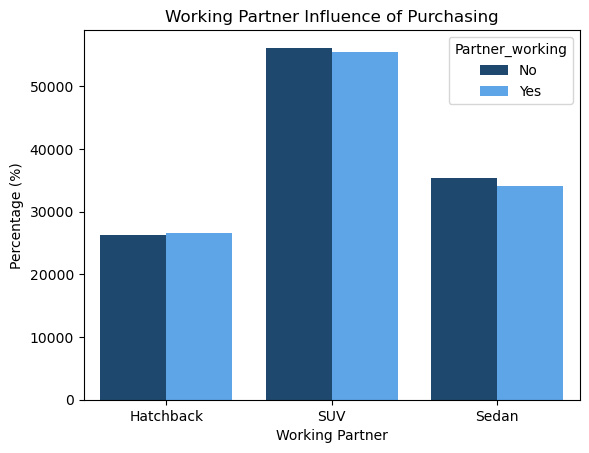

In [72]:
partner_influence = austo.groupby(['Partner_working','Make'])['Price'].mean().reset_index()
sns.barplot(data = partner_influence,x = 'Make',y = 'Price',hue = 'Partner_working',palette={'Yes': '#47A6FF', 'No': '#11497B'},ci = None)
plt.title('Working Partner Influence of Purchasing')
plt.xlabel('Working Partner')
plt.ylabel('Percentage (%)')
plt.show()

From the above observation, we can say that customers with working partners spend marginally more on Hatchbacks, but spend slightly less on SUVs and Sedans than those without a working partner.

**I wanted to check partner salary is benefiting men or women?**

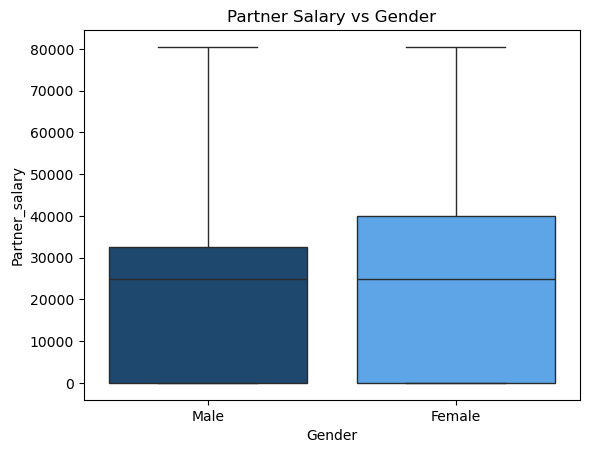

In [73]:
sns.boxplot(data = austo,x= 'Gender', y = 'Partner_salary',palette={'Female': '#47A6FF', 'Male': '#11497B'})
plt.title('Partner Salary vs Gender')
plt.show()

From the observation of the boxplot, partner salaries by gender shows that females tend to have higher partner salaries on average than males.
This indicates that female customers may benefit from dual-income households more often than male customers, This strengthens the earlier observation where 58% of SUV buyers were women.(Reference 1st Key Question). 